# Station-Level Analysis

This notebook is Phase 3, Section 4 of the Delhi AQI / GRAP project: **Station-Level
Analysis**.

**Scope of this notebook.** We describe how pollution and weather readings differ
across the eight monitoring stations, using summary statistics, ranking tables, and
distribution plots -- one station compared against another, nothing else.

**Deliberately out of scope here.** No GRAP stage analysis, no year-to-year
comparison, no causal reasoning about why any station differs from another, and no
conclusions about which station is "better" or "worse". Those questions are
recorded at the end of this notebook for later sections to take up.

> The notebook assumes it is run from the `notebooks/` folder, so the data path
> below starts with `../`. This notebook does not modify any earlier notebook.

# Section 1 -- Station Summary

We start by loading the merged Phase 2 dataset and computing one row of summary
statistics per station.

In [1]:
import pandas as pd

# Path to the merged analytical dataset built in Phase 2.
# This assumes the notebook is run from the 'notebooks/' folder.
data_path = '../data/processed/station_daily_grap.csv'

# Load the whole dataset into a DataFrame called df.
df = pd.read_csv(data_path)

df.head()

,station_id,station_name,date,year,pm25_ugm3,pm10_ugm3,air_temp_c,rh_pct,wind_speed_ms,wind_dir_deg,season,grap_stage,is_event_day,days_since_last_change,days_until_next_change,source_file
0,anand_vihar,Anand Vihar,2022-01-01,2022,393.56,598.82,13.97,75.32,0.32,230.10,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
1,anand_vihar,Anand Vihar,2022-01-02,2022,424.81,598.95,14.33,75.32,0.32,230.36,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
2,anand_vihar,Anand Vihar,2022-01-03,2022,375.52,636.12,14.79,72.44,0.35,223.51,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
3,anand_vihar,Anand Vihar,2022-01-04,2022,291.86,564.58,16.14,66.95,0.31,209.49,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"
4,anand_vihar,Anand Vihar,2022-01-05,2022,353.05,449.37,14.45,86.60,0.89,138.08,2021-22,0,0,NaN,NaN,"raw_data_data_anand_vihar,_delhi_-_dpcc_1D_22.csv"


**What this does.** Imports pandas and loads the merged Phase 2 dataset
(`station_daily_grap.csv`) into a DataFrame named `df`, then previews the first
five rows.

**Why grouping is useful.** Every station contributes many rows -- one per day -- so
looking at `df` directly mixes all stations together. Grouping by `station_name`
in the next step lets us collapse each station's many rows into a single row of
statistics, which is what makes a station-to-station comparison possible.

**What an analyst should look for.** Confirm the file loaded without error and
that `station_name` and the pollutant/weather columns are present and look as
expected before any grouping is attempted.

In [2]:
# Group the dataset by station and compute summary statistics for
# PM2.5, PM10, and the three weather variables in one call.
station_summary = df.groupby('station_name').agg(
    pm25_count=('pm25_ugm3', 'count'),
    pm25_mean=('pm25_ugm3', 'mean'),
    pm25_median=('pm25_ugm3', 'median'),
    pm25_std=('pm25_ugm3', 'std'),
    pm25_min=('pm25_ugm3', 'min'),
    pm25_max=('pm25_ugm3', 'max'),
    pm10_mean=('pm10_ugm3', 'mean'),
    pm10_median=('pm10_ugm3', 'median'),
    pm10_std=('pm10_ugm3', 'std'),
    mean_temp_c=('air_temp_c', 'mean'),
    mean_humidity_pct=('rh_pct', 'mean'),
    mean_wind_speed_ms=('wind_speed_ms', 'mean'),
)

# Round for readability and give the table a clean, consistent look.
station_summary = station_summary.round(2)
station_summary = station_summary.reset_index()

station_summary

,station_name,pm25_count,pm25_mean,pm25_median,pm25_std,pm25_min,pm25_max,pm10_mean,pm10_median,pm10_std,mean_temp_c,mean_humidity_pct,mean_wind_speed_ms
0,Anand Vihar,720,125.98,100.76,89.32,14.20,494.15,307.16,298.35,150.41,26.09,59.97,1.04
1,Bawana,720,118.11,95.60,83.26,7.83,505.64,245.94,239.32,133.38,24.90,62.91,0.84
2,Jawaharlal Nehru Stadium,711,92.87,70.94,72.09,5.21,416.92,189.27,178.65,104.73,25.40,64.43,1.38
3,Najafgarh,721,79.49,64.37,62.08,5.59,368.34,155.34,148.77,87.95,24.44,62.62,0.65
4,Narela,720,108.76,87.80,79.27,7.70,541.68,227.27,208.92,119.15,24.50,65.74,1.00
5,Okhla Phase-2,724,96.83,72.45,79.63,6.18,521.69,218.60,205.48,117.11,25.15,60.20,0.84
6,Punjabi Bagh,723,116.07,92.00,82.96,15.22,435.65,227.17,209.83,116.67,27.27,59.39,0.54
7,R K Puram,724,112.65,88.68,80.24,11.41,505.68,204.79,199.04,107.91,24.91,66.80,0.71


**What this does.** `groupby('station_name')` splits `df` into one group per
station. `.agg(...)` then computes, for each group, the count/mean/median/standard
deviation/minimum/maximum of PM2.5, the mean/median/standard deviation of PM10,
and the mean of temperature, humidity, and wind speed -- all in a single pass. The
result is rounded and turned into one clean table with one row per station.

**Why grouping is useful.** Grouping is the mechanism that turns a station-and-day
dataset into a station-only dataset. Without it, every statistic would describe
the city as a whole; with it, each statistic describes exactly one monitoring
site, which is the unit this notebook is built around.

**What an analyst should look for.** Check that every station has a row, that the
PM2.5 count looks reasonable relative to the number of days in the study, and that
no column is entirely blank. This table is the single source that every later
table and chart in this notebook is built from.

# Section 2 -- Ranking Tables

Using the station summary table above, we now sort stations along five different
dimensions. Each ranking answers a different question about the same underlying
numbers, and each is shown as its own table.

In [3]:
# Sort the station summary by mean PM2.5, highest first.
ranking_highest_mean_pm25 = station_summary[['station_name', 'pm25_mean']]
ranking_highest_mean_pm25 = ranking_highest_mean_pm25.sort_values(
    by='pm25_mean', ascending=False
).reset_index(drop=True)
ranking_highest_mean_pm25

,station_name,pm25_mean
0,Anand Vihar,125.98
1,Bawana,118.11
2,Punjabi Bagh,116.07
3,R K Puram,112.65
4,Narela,108.76
5,Okhla Phase-2,96.83
6,Jawaharlal Nehru Stadium,92.87
7,Najafgarh,79.49


**What this does.** Takes the station name and mean PM2.5 columns from the summary
table and sorts them from the highest average PM2.5 down to the lowest.

**Why grouping is useful.** The grouping step already reduced each station to one
mean value; sorting simply orders those eight numbers so they can be compared at a
glance instead of scanning an unordered table.

**What an analyst should look for.** Note which stations sit at the top and bottom
of this ordering and how large the gap is between neighbouring stations -- not why
the ordering looks the way it does.

In [4]:
# Sort the same mean PM2.5 column the other way, lowest first.
ranking_lowest_mean_pm25 = station_summary[['station_name', 'pm25_mean']]
ranking_lowest_mean_pm25 = ranking_lowest_mean_pm25.sort_values(
    by='pm25_mean', ascending=True
).reset_index(drop=True)
ranking_lowest_mean_pm25

,station_name,pm25_mean
0,Najafgarh,79.49
1,Jawaharlal Nehru Stadium,92.87
2,Okhla Phase-2,96.83
3,Narela,108.76
4,R K Puram,112.65
5,Punjabi Bagh,116.07
6,Bawana,118.11
7,Anand Vihar,125.98


**What this does.** Uses the same mean PM2.5 column as above, but sorts from the
lowest average PM2.5 up to the highest -- the mirror image of the previous table.

**Why grouping is useful.** Because the mean was already computed once per station
in Section 1, this ranking costs nothing more than a re-sort -- a reminder of why
computing a clean grouped table first, before any ranking, is worth doing.

**What an analyst should look for.** Compare this table's top rows against the
previous table's bottom rows -- they should be the same stations in reverse order.
Use it to see which stations anchor the low end of the range.

In [5]:
# Sort stations by median PM2.5, highest first.
ranking_highest_median_pm25 = station_summary[['station_name', 'pm25_median']]
ranking_highest_median_pm25 = ranking_highest_median_pm25.sort_values(
    by='pm25_median', ascending=False
).reset_index(drop=True)
ranking_highest_median_pm25

,station_name,pm25_median
0,Anand Vihar,100.76
1,Bawana,95.60
2,Punjabi Bagh,92.00
3,R K Puram,88.68
4,Narela,87.80
5,Okhla Phase-2,72.45
6,Jawaharlal Nehru Stadium,70.94
7,Najafgarh,64.37


**What this does.** Sorts stations by median PM2.5 (the middle value at each
station) from highest to lowest, separately from the mean-based ranking above.

**Why grouping is useful.** Grouping produced both a mean and a median for every
station in one step, which makes it possible to rank the same stations two
different ways without recomputing anything from the raw data.

**What an analyst should look for.** Check whether this ordering matches the
mean-based ranking or differs from it -- a station whose position changes between
mean and median rankings is worth noting for later, without explaining it here.

In [6]:
# Sort stations by the standard deviation of PM2.5, most spread out first.
ranking_highest_pm25_variability = station_summary[['station_name', 'pm25_std']]
ranking_highest_pm25_variability = ranking_highest_pm25_variability.sort_values(
    by='pm25_std', ascending=False
).reset_index(drop=True)
ranking_highest_pm25_variability

,station_name,pm25_std
0,Anand Vihar,89.32
1,Bawana,83.26
2,Punjabi Bagh,82.96
3,R K Puram,80.24
4,Okhla Phase-2,79.63
5,Narela,79.27
6,Jawaharlal Nehru Stadium,72.09
7,Najafgarh,62.08


**What this does.** Sorts stations by the standard deviation of PM2.5, from most
spread out to most tightly clustered.

**Why grouping is useful.** Standard deviation, like the mean and median, is
computed once per station by the grouping step in Section 1 -- this table simply
reorders that single column to highlight spread instead of level.

**What an analyst should look for.** Notice that a high standard deviation is a
statement about spread, not about level -- a station can have a high or low
standard deviation independently of where it ranks in the mean or median tables
above. Keep the two kinds of ranking (level vs. spread) mentally separate.

In [7]:
# Sort stations by the single highest PM2.5 value ever recorded there.
ranking_highest_recorded_pm25 = station_summary[['station_name', 'pm25_max']]
ranking_highest_recorded_pm25 = ranking_highest_recorded_pm25.sort_values(
    by='pm25_max', ascending=False
).reset_index(drop=True)
ranking_highest_recorded_pm25

,station_name,pm25_max
0,Narela,541.68
1,Okhla Phase-2,521.69
2,R K Puram,505.68
3,Bawana,505.64
4,Anand Vihar,494.15
5,Punjabi Bagh,435.65
6,Jawaharlal Nehru Stadium,416.92
7,Najafgarh,368.34


**What this does.** Sorts stations by the single highest PM2.5 value ever recorded
at that station, from largest to smallest.

**Why grouping is useful.** The grouped `max` in Section 1 already reduced each
station's full history down to its one most extreme day; this table just orders
those eight extreme values against each other.

**What an analyst should look for.** Remember that this ranking reflects a single
day at each station, not its typical behaviour -- a station can rank low on average
PM2.5 in the earlier tables and still hold the single highest recorded value here.

# Section 3 -- Visualisations

We now look at the same station-level differences visually: two box plots (showing
full distributions) and two bar charts (showing single summary values) for PM2.5
and PM10. All charts use matplotlib only.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_23568\2369306013.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pm25_by_station, labels=stations_in_order)


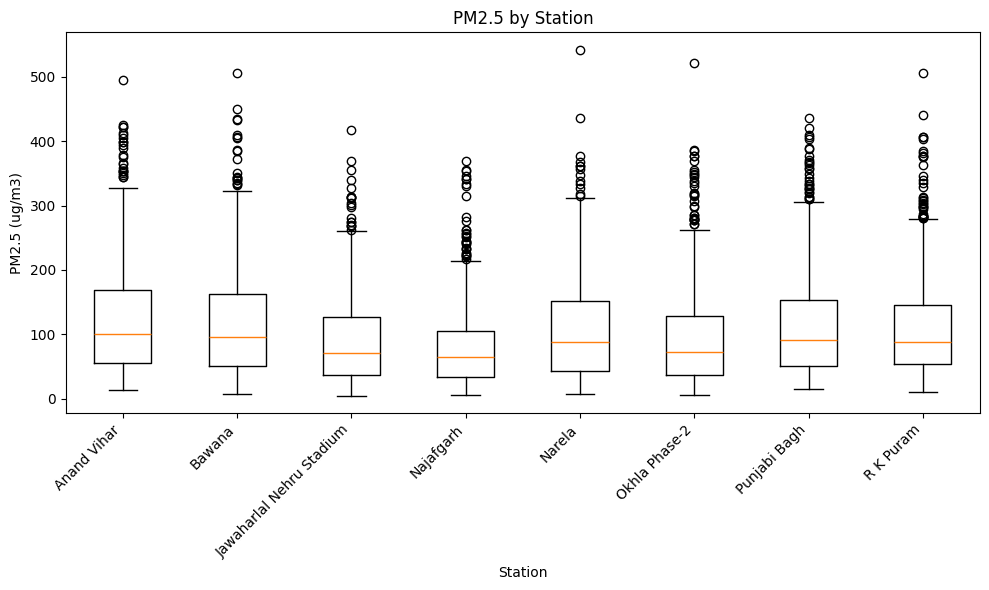

In [8]:
import matplotlib.pyplot as plt

# Build one list of PM2.5 values per station, in the same station order as
# the summary table, dropping missing values since a box plot cannot use them.
stations_in_order = station_summary['station_name'].tolist()
pm25_by_station = [
    df.loc[df['station_name'] == station, 'pm25_ugm3'].dropna()
    for station in stations_in_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(pm25_by_station, labels=stations_in_order)
plt.title('PM2.5 by Station')
plt.xlabel('Station')
plt.ylabel('PM2.5 (ug/m3)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Builds one array of PM2.5 values per station, in the station
order used throughout this notebook, and draws a separate box (median, quartiles,
whiskers, and outliers) for each station on the same axes.

**Why grouping is useful.** A box plot needs its data pre-split into one group per
category before it can draw anything; grouping by station is exactly what supplies
those separate arrays, one per box.

**What an analyst should look for.** Compare the boxes side by side: which
stations have taller boxes (more spread) versus shorter ones, where the medians
sit relative to each other, and how many outlier points appear above each box.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_23568\2471776377.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pm10_by_station, labels=stations_in_order)


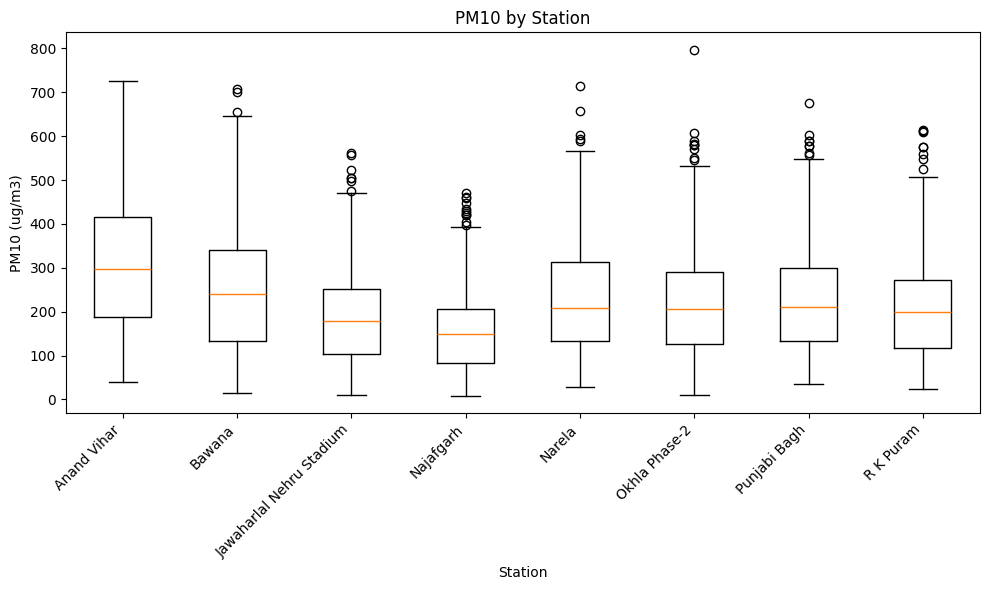

In [9]:
# Repeat the same construction for PM10, keeping the station order fixed
# so the two box plots are directly comparable.
pm10_by_station = [
    df.loc[df['station_name'] == station, 'pm10_ugm3'].dropna()
    for station in stations_in_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(pm10_by_station, labels=stations_in_order)
plt.title('PM10 by Station')
plt.xlabel('Station')
plt.ylabel('PM10 (ug/m3)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Repeats the same box plot construction as above, this time
using PM10 values, keeping the stations in the same fixed order for easy
comparison against the PM2.5 box plot.

**Why grouping is useful.** Reusing the same per-station grouping (and the same
station order) for a second pollutant makes the two box plots directly comparable
figure-to-figure, rather than each using its own arrangement.

**What an analyst should look for.** As with PM2.5, compare box heights, median
positions, and outliers across stations -- and also compare this plot's shape
against the PM2.5 box plot to see whether the two pollutants tell a similar story
at each station.

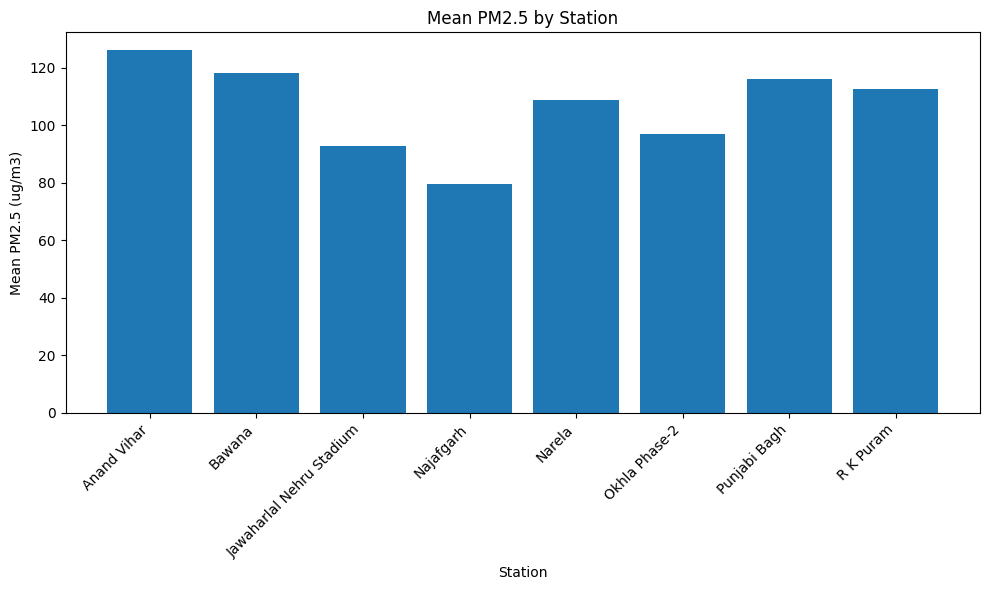

In [10]:
# One bar per station, height equal to that station's mean PM2.5.
plt.figure(figsize=(10, 6))
plt.bar(station_summary['station_name'], station_summary['pm25_mean'])
plt.title('Mean PM2.5 by Station')
plt.xlabel('Station')
plt.ylabel('Mean PM2.5 (ug/m3)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Draws one bar per station, with the bar's height equal to that
station's mean PM2.5 from the Section 1 summary table.

**Why grouping is useful.** The mean plotted here is only meaningful because it was
already computed per station by the groupby step -- the bar chart is simply a
visual rendering of one column of that grouped table.

**What an analyst should look for.** Scan for the tallest and shortest bars and how
gradually or sharply the bar heights change moving from one station to the next.

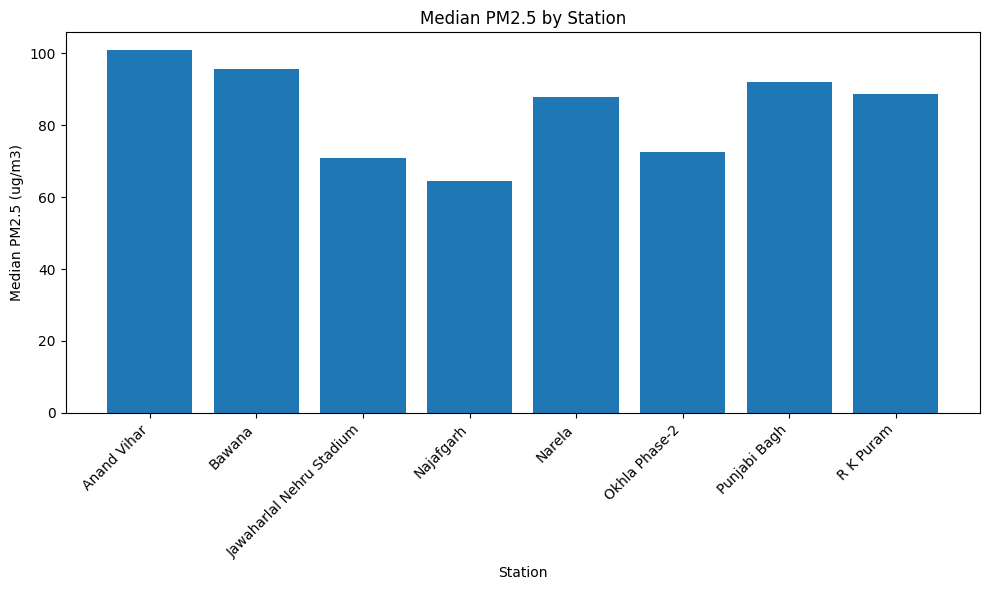

In [11]:
# One bar per station, height equal to that station's median PM2.5,
# using the same station order as the mean bar chart above.
plt.figure(figsize=(10, 6))
plt.bar(station_summary['station_name'], station_summary['pm25_median'])
plt.title('Median PM2.5 by Station')
plt.xlabel('Station')
plt.ylabel('Median PM2.5 (ug/m3)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this does.** Draws one bar per station, with the bar's height equal to that
station's median PM2.5, using the same station order as the mean bar chart above.

**Why grouping is useful.** As with the mean bar chart, this chart only exists
because grouping already reduced each station to a single median value -- plotting
it is a one-line step once the grouped table is in hand.

**What an analyst should look for.** Compare this chart bar-by-bar against the mean
bar chart above: bars that change height or ordering between the two charts point
to a difference between a station's typical day and its average that is worth
carrying into later analysis.

## Questions Raised

Comparing stations above naturally raises the following questions. They are
recorded here as a to-do list for later sections -- **they are not answered in
this Station-Level Analysis notebook.**

1. Why is the highest-PM2.5 station consistently higher than the others?
2. Why is the lowest-PM2.5 station consistently lower than the others?
3. Are the differences between stations stable across seasons, or do they shift
   from one season to another?
4. Do PM2.5 and PM10 distributions differ in shape from station to station, or only
   in level?
5. Does the station with the highest variability also have the most missing data,
   or the most flagged impossible values?
6. Do stations that rank close together on mean PM2.5 also rank close together on
   median PM2.5, or does the ordering change?
7. Is the single highest recorded PM2.5 value at each station an isolated event, or
   part of a longer high-pollution stretch?
8. Do weather variables (temperature, humidity, wind speed) differ across stations
   in a way that lines up with the pollutant differences?
9. Are station-to-station differences consistent across the two years in the
   dataset, or do they change from year to year?
10. Do the stations group into clusters of similar behaviour, or does each station
    stand apart from the others?

*End of the Station-Level Analysis notebook.*